## Collection of the output plots for presenting results

In [ ]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Arc

from helpers import IFMRHandler

In [ ]:
mag_range = [[-0.5,1.65],[-5,18.5]]  # col-mag ranges
mag_step = [0.02,0.2]                # col-mag resolution

### Hess diagram (Data)

In [7]:
# Definitions of population boundaries
x = np.arange(mag_range[0][0] + mag_step[0]/2,mag_range[0][1] + mag_step[0]/2,mag_step[0])
y = np.arange(mag_range[1][0] + mag_step[1]/2,mag_range[1][1] + mag_step[1]/2,mag_step[1])

y1 = 6*x + 9.8
y2 = x*0 + 4.3
y3 = 35*x - 15
y4 = x*0 + 8.5

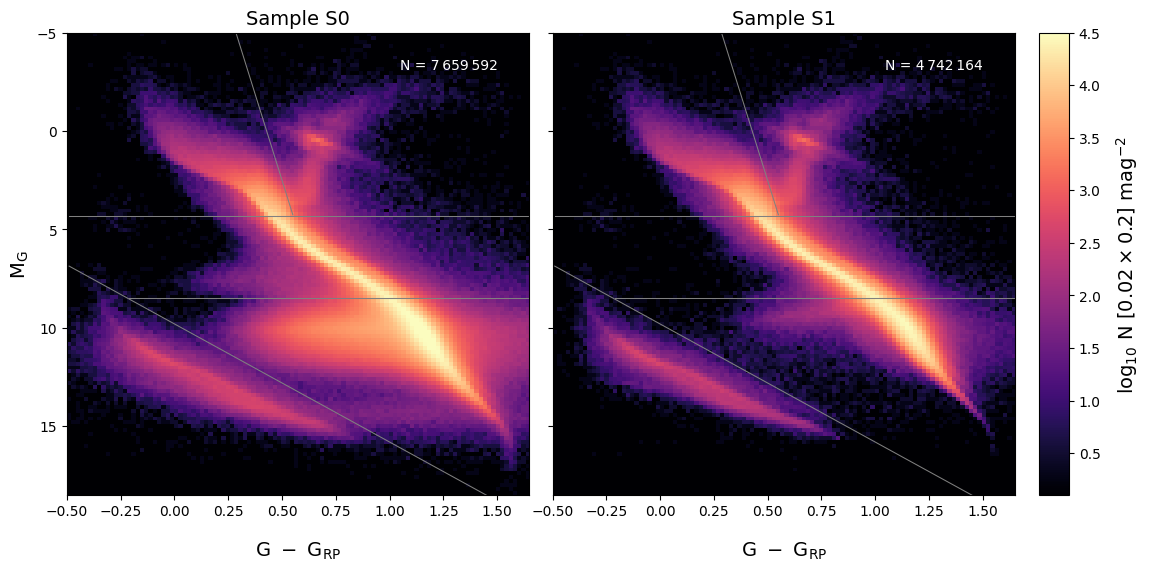

In [ ]:
# Data 
hess_s0 = np.loadtxt('data/hess/hess_1kpc_s0.txt')
hess_s1 = np.loadtxt('data/hess/hess_1kpc_s1.txt')

lw_bounds = 0.75
fnt_main = 14

Ntot_s0 = int(round(sum(sum(hess_s0)),0))
Ntot_s1 = int(round(sum(sum(hess_s1)),0))

# Data Hess diagram
# ---------------------
fig, ax = plt.subplots(1,2,figsize=(12,6),sharey=True)

# Sample S0
im1 = ax[0].imshow(np.log10(hess_s0+1),interpolation=None,cmap=mpl.colormaps['magma'],
               extent=[mag_range[0][0],mag_range[0][1],mag_range[1][1],mag_range[1][0]],
               vmin=0.1,vmax=4.5)
# population boundaries
ax[0].plot(x,y1,c='grey',lw=lw_bounds)
ax[0].plot(x,y2,c='grey',lw=lw_bounds)
ax[0].plot(x[:53],y3[:53],c='grey',lw=lw_bounds)
ax[0].plot(x[14:],y4[14:],c='grey',lw=lw_bounds)

ax[0].set_xlim(mag_range[0][0],mag_range[0][1])
ax[0].set_ylim(mag_range[1][1],mag_range[1][0])

ax[0].text(0.72,0.92,'N = '+f"{Ntot_s0:,}".replace(",", "\u2009"),
           color='w',transform=ax[0].transAxes)

ax[0].set_aspect(abs((mag_range[0][1]-mag_range[0][0])/(mag_range[1][1]-mag_range[1][0])))
ax[0].set_title('Sample S0',fontsize=14)
ax[0].set_xlabel(r'$\mathrm{G \ - \ G_{RP}}$',labelpad=15,fontsize=fnt_main)
ax[0].set_ylabel(r'$\mathrm{M_G}$',fontsize=fnt_main)

# Smaple S1
ax[1].imshow(np.log10(hess_s1+1),interpolation=None,cmap=mpl.colormaps['magma'],
               extent=[mag_range[0][0],mag_range[0][1],mag_range[1][1],mag_range[1][0]],
               vmin=0.1,vmax=4.5)
# population boundaries
ax[1].plot(x,y1,c='grey',lw=lw_bounds)
ax[1].plot(x,y2,c='grey',lw=lw_bounds)
ax[1].plot(x[:53],y3[:53],c='grey',lw=lw_bounds)
ax[1].plot(x[14:],y4[14:],c='grey',lw=lw_bounds)

ax[1].set_xlim(mag_range[0][0],mag_range[0][1])
ax[1].set_ylim(mag_range[1][1],mag_range[1][0])

ax[1].set_aspect(abs((mag_range[0][1]-mag_range[0][0])/(mag_range[1][1]-mag_range[1][0])))
ax[1].text(0.72,0.92,'N = '+f"{Ntot_s1:,}".replace(",", "\u2009"),
           color='w',transform=ax[1].transAxes)
ax[1].set_title('Sample S1',fontsize=fnt_main)
ax[1].set_xlabel(r'$\mathrm{G \ - \ G_{RP}}$',labelpad=15,fontsize=fnt_main)

fig.subplots_adjust(left=0.07,wspace=0.05,right=0.86,top=0.93)
pos = ax[1].get_position()
cax = fig.add_axes([pos.x0+pos.width+0.02,pos.y0,0.025,pos.height])
cbar = fig.colorbar(im1,cax=cax,orientation='vertical')
cbar.set_label(r'$\mathrm{log_{10} \ N \ [' + str(mag_step[0]) +
               r'\times' + str(mag_step[1]) + r'] \ mag^{-2}}$',labelpad=10,fontsize=fnt_main)

plt.savefig('output/final_plots/cmd_data_s01_bounds.png')


### Hess diagram (Data and SJ21 Model)

/tmp/ipykernel_59512/1209914316.py:44: RuntimeWarning: divide by zero encountered in divide
  diff = np.log10((hess_m - hess_d)**2 / (hess_d + 0.1*hess_d**2))
/tmp/ipykernel_59512/1209914316.py:44: RuntimeWarning: invalid value encountered in divide
  diff = np.log10((hess_m - hess_d)**2 / (hess_d + 0.1*hess_d**2))


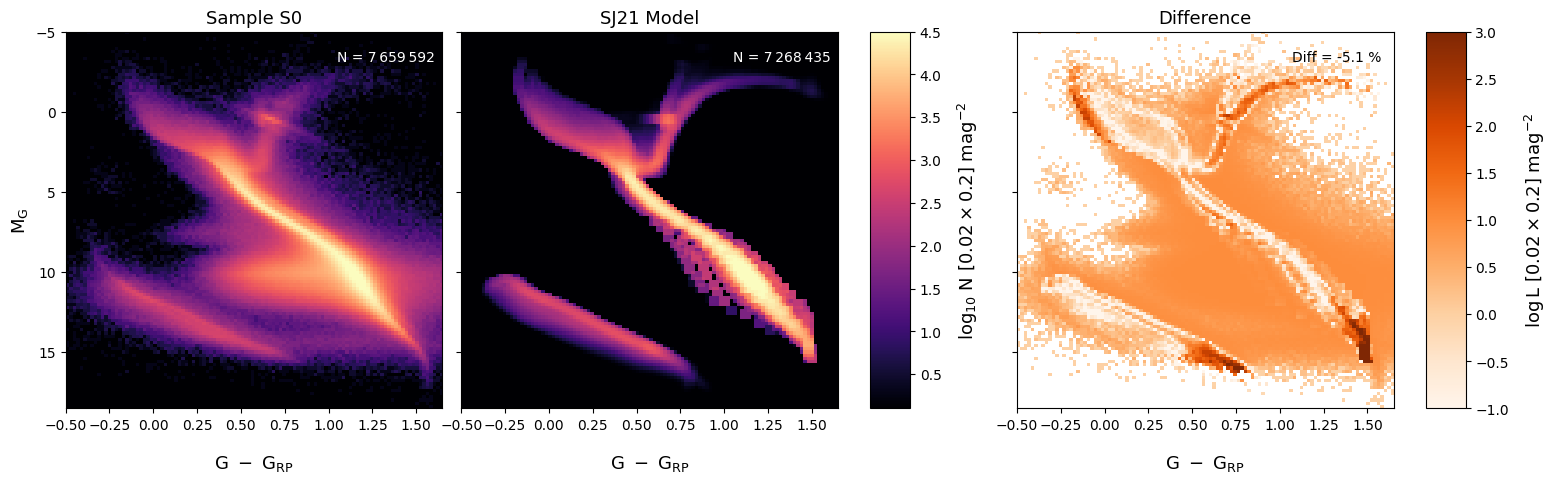

In [47]:
hess_d = np.loadtxt('data/hess/hess_1kpc_s0.txt')
hess_m = np.loadtxt('output/CMDF/hess_default_model.txt')
hess_m = np.loadtxt('output/CMDF/hess_pop5.txt')

fnt_main = 13


Ntot_d = int(round(sum(sum(hess_d)),0))
Ntot_m = int(round(sum(sum(hess_m)),0))

fig, ax = plt.subplots(1,3,figsize=(16,5.5),sharey=True)

# Data
im1 = ax[0].imshow(np.log10(hess_d+1),interpolation=None,cmap=mpl.colormaps['magma'],
               extent=[mag_range[0][0],mag_range[0][1],mag_range[1][1],mag_range[1][0]],
               vmin=0.1,vmax=4.5)
ax[0].text(0.72,0.92,'N = '+f"{Ntot_d:,}".replace(",", "\u2009"),color='w',transform=ax[0].transAxes)
ax[0].set_aspect(abs((mag_range[0][1]-mag_range[0][0])/(mag_range[1][1]-mag_range[1][0])))
ax[0].set_title('Sample S0',fontsize=fnt_main)
ax[0].set_xlabel(r'$\mathrm{G \ - \ G_{RP}}$',labelpad=15,fontsize=fnt_main)
ax[0].set_ylabel(r'$\mathrm{M_G}$',fontsize=fnt_main)

# Model
ax[1].imshow(np.log10(hess_m+1),interpolation=None,cmap=mpl.colormaps['magma'],
               extent=[mag_range[0][0],mag_range[0][1],mag_range[1][1],mag_range[1][0]],
               vmin=0.1,vmax=4.5)
ax[1].set_aspect(abs((mag_range[0][1]-mag_range[0][0])/(mag_range[1][1]-mag_range[1][0])))
ax[1].text(0.72,0.92,'N = '+f"{Ntot_m:,}".replace(",", "\u2009"),color='w',transform=ax[1].transAxes)
#ax[1].set_title('Model (' + mode_iso + ')')['d']
ax[1].set_title('SJ21 Model',fontsize=fnt_main)
ax[1].set_xlabel(r'$\mathrm{G \ - \ G_{RP}}$',labelpad=15,fontsize=fnt_main)


fig.subplots_adjust(left=0.05,wspace=0.05,right=0.78,top=0.93)
pos = ax[1].get_position()
cax = fig.add_axes([pos.x0+pos.width+0.02,pos.y0,0.025,pos.height])
cbar = fig.colorbar(im1,cax=cax,orientation='vertical')
cbar.set_label(r'$\mathrm{log_{10} \ N \ [' + str(mag_step[0]) +
               r'\times' + str(mag_step[1]) + r'] \ mag^{-2}}$',labelpad=10,fontsize=fnt_main)

# Difference
eps = 1e-2

diff = np.log10((hess_m - hess_d)**2 / (hess_d + 0.1*hess_d**2))
#diff = (np.log10(hess_m+eps) - np.log10(hess_d+eps))#/(hess + 1)
#diff = hess_m - hess_d

pos_x2 = ax[2].get_position()
ax[2].set_position([pos_x2.x0+0.1,pos_x2.y0,pos_x2.width,pos_x2.height])

im2 = ax[2].imshow(diff,interpolation=None,cmap=mpl.colormaps['Oranges'], # RdBu_r Oranges
               extent=[mag_range[0][0],mag_range[0][1],mag_range[1][1],mag_range[1][0]],
               vmin=-1,vmax=3) # -1 3
ax[2].text(0.73,0.92,'Diff = '+str(np.round(100*(Ntot_m-Ntot_d)/Ntot_d,1))+' %',
           color='k',transform=ax[2].transAxes)
ax[2].set_aspect(abs((mag_range[0][1]-mag_range[0][0])/(mag_range[1][1]-mag_range[1][0])))
ax[2].set_xlabel(r'$\mathrm{G \ - \ G_{RP}}$',labelpad=15,fontsize=fnt_main)
#ax[2].set_title('Log likelihood',fontsize=fnt_main)
ax[2].set_title('Log ratio',fontsize=fnt_main)
ax[2].set_title('Difference',fontsize=fnt_main)

pos2_new = ax[2].get_position()
cax = fig.add_axes([pos2_new.x0+pos2_new.width+0.02,pos2_new.y0,0.025,pos2_new.height])
cbar = fig.colorbar(im2,cax=cax,orientation='vertical')
cbar.set_label(r'$\mathrm{\log{L} \ [' + str(mag_step[0]) +
               r'\times' + str(mag_step[1]) + r'] \ mag^{-2}}$',labelpad=10,fontsize=fnt_main)
#cbar.set_label(r'$\mathrm{log_{10}(N_{m}/N_{d}) \ [' + str(mag_step[0]) +
#               r'\times' + str(mag_step[1]) + r'] \ mag^{-2}}$',labelpad=10,fontsize=fnt_main)
#cbar.set_label(r'$\mathrm{(N_{m} - N_{d}) \ [' + str(mag_step[0]) +
#               r'\times' + str(mag_step[1]) + r'] \ mag^{-2}}$',labelpad=10,fontsize=fnt_main)


plt.savefig('output/final_plots/hess_m2d_logl_pop5.png')
#plt.savefig('output/final_plots/hess_m2d_logr_pop5.png')
#plt.savefig('output/final_plots/hess_m2d_diff_pop5.png')


## Color and magnitude distributions

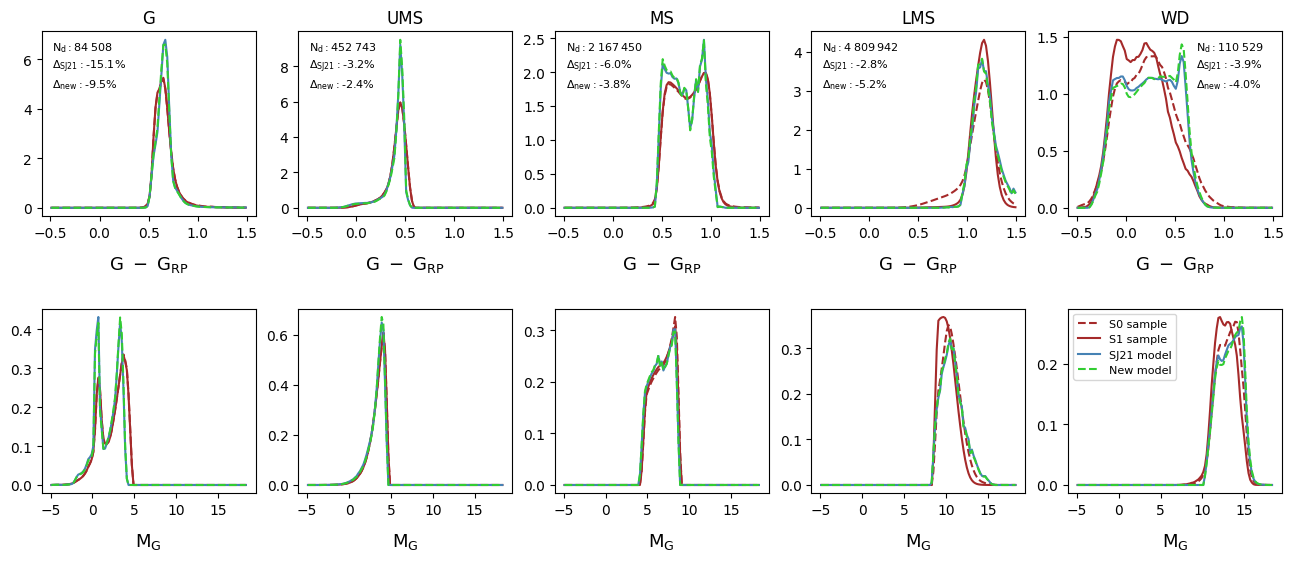

In [16]:
def read_cmf_data(pops=['wd','ms','ums','lms','g'],source_dir='./data/1kpc/'):

    coldata_d = {pop:{'SCD_S0':[],'SCD_S1':[],'NSCD_S0':[],'NSCD_S1':[]} for pop in pops}
    magdata_d = {pop:{'SMD_S0':[],'SMD_S1':[],'NSMD_S0':[],'NSMD_S1':[]} for pop in pops}

    for pop in pops:
        cdf = np.loadtxt(source_dir + 'coldist/nsdf_' + pop + '.txt')
        coldata_d[pop]['SCD_S0'] = cdf[:,2]
        coldata_d[pop]['SCD_S1'] = cdf[:,3]
        coldata_d[pop]['NSCD_S0'] = cdf[:,4]
        coldata_d[pop]['NSCD_S1'] = cdf[:,5]

        mdf = np.loadtxt(source_dir + 'magdist/nsdf_' + pop + '.txt')
        magdata_d[pop]['SMD_S0'] = mdf[:,2]
        magdata_d[pop]['SMD_S1'] = mdf[:,3]
        magdata_d[pop]['NSMD_S0'] = mdf[:,4]
        magdata_d[pop]['NSMD_S1'] = mdf[:,5]

    coldata_d['LOW'] = np.round(cdf[:,0],2)
    coldata_d['HIGH'] = np.round(cdf[:,1],2)

    magdata_d['LOW'] = np.round(mdf[:,0],2)
    magdata_d['HIGH'] = np.round(mdf[:,1],2)

    return coldata_d, magdata_d


def read_cmf_model(pops=['wd','ms','ums','lms','g'],
                   source_dir='./output/CMDF/',
                   model='default_model'):

    # Read model 
    coldata_m = {pop:{'SCD':[],'NSCD':[]} for pop in pops}
    magdata_m = {pop:{'SMD':[],'NSMD':[]} for pop in pops}

    for pop in pops:
        cdf = np.loadtxt(source_dir + 'cdf_' + model + '_' + pop + '.txt')
        coldata_m[pop]['SCD'] = cdf[:,0]
        coldata_m[pop]['NSCD'] = cdf[:,1]

        mdf = np.loadtxt(source_dir + 'mdf_' + model + '_' + pop + '.txt')
        magdata_m[pop]['SMD'] = mdf[:,0]
        magdata_m[pop]['NSMD'] = mdf[:,1]

    return coldata_m, magdata_m

pops=['g','ums','ms','lms','wd']

coldata_d, magdata_d = read_cmf_data()
coldata_m, magdata_m = read_cmf_model()
coldata_m_new, magdata_m_new = read_cmf_model(model='pop4')

ind_c = 100
ind_m = 117

fig, ax = plt.subplots(2,5,figsize=(16,6))
for i,pop in enumerate(pops):

    n_data = int(coldata_d[pop]['SCD_S0'][:ind_c].sum())
    n_model = int(round(coldata_m[pop]['SCD'][:ind_c].sum(),0))
    n_model_new = int(round(coldata_m_new[pop]['SCD'][:ind_c].sum(),0))
    diff = round((n_model - n_data)/n_data*100,1)
    diff_new = round((n_model_new - n_data)/n_data*100,1)

    x_loc = 0.05
    if pop=='wd':
        x_loc = 0.6
    ax[0,i].plot(x[:ind_c],coldata_d[pop]['NSCD_S0'][:ind_c],ls='--',c='brown')
    ax[0,i].plot(x[:ind_c],coldata_d[pop]['NSCD_S1'][:ind_c],c='brown')
    ax[0,i].plot(x[:ind_c],coldata_m[pop]['NSCD'][:ind_c],c='steelblue')
    ax[0,i].plot(x[:ind_c],coldata_m_new[pop]['NSCD'][:ind_c],ls='--',c='limegreen')
    ax[0,i].set_xlabel(r'$\mathrm{G \ - \ G_{RP}}$',labelpad=10,fontsize=fnt_main)
    ax[0,i].text(x_loc,0.9,r'$\mathrm{N_d: }$' + f"{n_data:,}".replace(",", "\u2009"),
            color='k',transform=ax[0,i].transAxes,fontsize=8)
    ax[0,i].text(x_loc,0.8,r'$\mathrm{\Delta_{SJ21}: }$'+f"{diff:+}"+'%',
            color='k',transform=ax[0,i].transAxes,fontsize=8)
    ax[0,i].text(x_loc,0.7,r'$\mathrm{\Delta_{new}: }$'+f"{diff_new:+}"+'%',
            color='k',transform=ax[0,i].transAxes,fontsize=8)
    ax[1,i].set_xticks([-0.5,0,0.5,1.0,1.5])
    ax[0,i].set_title(pop.upper())
    

    ax[1,i].plot(y[:ind_m],magdata_d[pop]['NSMD_S0'][:ind_m],ls='--',c='brown',label='S0 sample')
    ax[1,i].plot(y[:ind_m],magdata_d[pop]['NSMD_S1'][:ind_m],c='brown',label='S1 sample')
    ax[1,i].plot(y[:ind_m],magdata_m[pop]['NSMD'][:ind_m],c='steelblue',label='SJ21 model')
    ax[1,i].plot(y[:ind_m],magdata_m_new[pop]['NSMD'][:ind_m],ls='--',c='limegreen',label='New model')
    ax[1,i].set_xticks([-5,0,5,10,15])
    ax[1,i].set_xlabel(r'$\mathrm{M_G}$',labelpad=10,fontsize=fnt_main)
    if i==4:
        ax[1,i].legend(loc=2,prop={'size':8})

fig.subplots_adjust(hspace=0.5)
fig.savefig('./output/final_plots/cmdf_pop4.png')


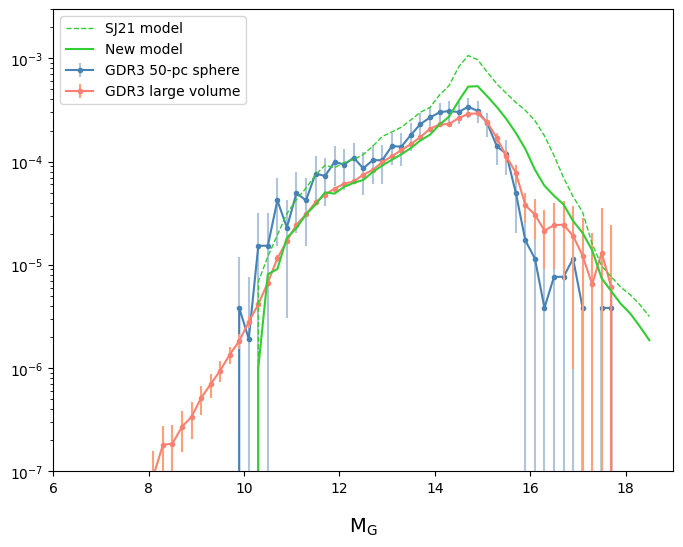

In [42]:
# WD luminosity function

mg_bins_m, wdlf_m = np.loadtxt('./output/WDLF/wdlf_sj21.txt')
mg_bins_m_pop2, wdlf_m_pop2 = np.loadtxt('./output/WDLF/wdlf_pop5.txt')
mg_bins_d, wdlf_d, wdlf_ed = np.loadtxt('./output/WDLF/wdlf_myvolume_data.txt')
mg_bins_d_50, wdlf_d_50, wdlf_ed_50 = np.loadtxt('./output/WDLF/wdlf_50pc_data.txt')

fig, ax = plt.subplots(1,1,figsize=(8,6))
ax.errorbar(mg_bins_d_50,wdlf_d_50,yerr=3*wdlf_ed_50,marker='o',markersize=3,
            c='steelblue',ecolor='lightsteelblue',label='GDR3 50-pc sphere',zorder=10)
ax.errorbar(mg_bins_d,wdlf_d,yerr=3*wdlf_ed,marker='o',markersize=3,
            c='salmon',ecolor='lightsalmon',label='GDR3 large volume',zorder=20)

ax.plot(mg_bins_m,wdlf_m,c='limegreen',label='SJ21 model',lw=1.0,zorder=30,ls='--')
ax.plot(mg_bins_m_pop2,wdlf_m_pop2,c='limegreen',label='New model',lw=1.5,zorder=40)

ax.set_yscale('log')
ax.set_xlim(6,19)
ax.set_ylim(1e-7,3e-3)
ax.set_xlabel(r'$\mathrm{M_G}$',labelpad=15,fontsize=14)
plt.legend(loc=2)

fig.savefig('./output/final_plots/WDLF_pop5.png')

### Sample geometry (plot from SJ21)

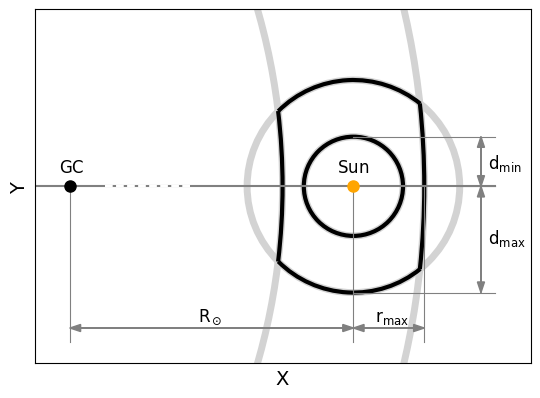

In [ ]:
plt.figure()
ax = plt.gca()
ax.set_aspect('equal')
ax.set_xlim(-4.5,2.5)
ax.set_ylim(-2.5,2.5)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel(r'$\mathrm{X}$',fontsize=14)
ax.set_ylabel(r'$\mathrm{Y}$',fontsize=14)

# circles
inner1 = plt.Circle((0.0,0.0),0.7,fill=False,color='lightgrey',lw=5)
inner2 = plt.Circle((0.0,0.0),0.7,fill=False,color='k',lw=3)
outer = plt.Circle((0.0,0.0),1.5,fill=False,color='lightgrey',lw=5)
# RC shell
rc_inner = plt.Circle((-10,0.0),9,fill=False,color='lightgrey',lw=5)
rc_outer = plt.Circle((-10,0.0),11,fill=False,color='lightgrey',lw=5)
# boundary
arc_outer1 = Arc((0,0),3,3,theta1=-135,theta2=-51,fill=False,color='k',lw=3)
arc_outer2 = Arc((0,0),3,3,theta1=51,theta2=135,fill=False,color='k',lw=3)
rc_arc_inner = Arc((-10,0.0),18,18,theta1=-6.78,theta2=6.78,fill=False,color='k',lw=3)
rc_arc_outer = Arc((-10,0.0),22,22,theta1=-6.1,theta2=6.1,fill=False,color='k',lw=3)

ax.plot([-4.5,2],[0.0,0.0],c='grey')
ax.plot([-3.5,-2.3],[0,0],c='w',ls='--')

ax.add_artist(inner1)
ax.add_artist(inner2)
ax.add_artist(outer)
ax.add_artist(rc_inner)
ax.add_artist(rc_outer)
ax.add_artist(rc_arc_inner)
ax.add_artist(rc_arc_outer)
ax.add_artist(arc_outer1)
ax.add_artist(arc_outer2)

plt.plot([-4,-4],[0,-2.2],c='grey',lw=0.8)
plt.plot([0,0],[0,-2.2],c='grey',lw=0.8)
plt.plot([1,1],[0,-2.2],c='grey',lw=0.8)
plt.plot([1.5,2.0],[0,0],c='grey',lw=0.8)
plt.plot([0,2.0],[0.7,0.7],c='grey',lw=0.8)
plt.plot([0,2.0],[-1.5,-1.5],c='grey',lw=0.8)
ax.arrow(-4,-2,4,0,color='grey',head_width=0.1,length_includes_head=True)
ax.arrow(0,-2,-4,0,color='grey',head_width=0.1,length_includes_head=True)
ax.annotate(r'$\mathrm{R_\odot}$',[-2.2,-1.9],fontsize=12)
ax.arrow(0,-2,1,0,color='grey',head_width=0.1,length_includes_head=True)
ax.arrow(1,-2,-1,0,color='grey',head_width=0.1,length_includes_head=True)
ax.annotate(r'$\mathrm{r_{max}}$',[0.3,-1.9],fontsize=12)
ax.arrow(1.8,0,0,0.7,color='grey',head_width=0.1,length_includes_head=True)
ax.arrow(1.8,0.7,0,-0.7,color='grey',head_width=0.1,length_includes_head=True)
ax.annotate(r'$\mathrm{d_{min}}$',[1.9,0.25],fontsize=12)
ax.arrow(1.8,0.0,0,-1.5,color='grey',head_width=0.1,length_includes_head=True)
ax.arrow(1.8,-1.5,0,1.5,color='grey',head_width=0.1,length_includes_head=True)
ax.annotate(r'$\mathrm{d_{max}}$',[1.9,-0.8],fontsize=12)

plt.plot([-4],[0],marker='o',markersize=8,color='k')
ax.plot([0],[0],marker='o',markersize=8,color='orange')
plt.annotate(r'$\mathrm{GC}$',[-4.15,0.2],fontsize=12)
plt.annotate(r'$\mathrm{Sun}$',[-0.23,0.2],fontsize=12)

plt.savefig('output/final_plots/sample_geometry.png')

### Initial-final mass relation

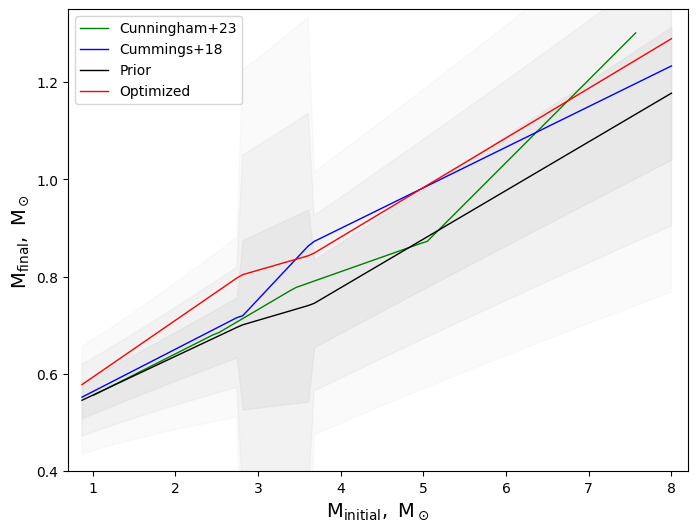

In [ ]:

ifmr = IFMRHandler()

x = np.linspace(0.87, 8.0, 100)

y0, sigma_y0, sigma_x0 = ifmr.cunningham(x)

# pop4 prior
y1, sigma_y1, sigma_x1 = ifmr.cummings(x)

# pop5 prior
alpha1, alpha2, alpha3 = 0.08, 0.05, 0.1
ifmr.update_ifmr(**{'alpha1': alpha1, 'alpha2': alpha2, 'alpha3': alpha3})
y2, sigma_y2, _ = ifmr.cummings(x)

# pop4
alpha1, alpha2, alpha3 = 0.119, 0.177, 0.088
ifmr.update_ifmr(**{'alpha1': alpha1, 'alpha2': alpha2, 'alpha3': alpha3})
y3, sigma_y3, _ = ifmr.cummings(x)

# pop5
alpha1, alpha2, alpha3 = 0.117,  0.049,  0.102
ifmr.update_ifmr(**{'alpha1': alpha1, 'alpha2': alpha2, 'alpha3': alpha3})
y4, sigma_y4, _ = ifmr.cummings(x)


plt.figure(figsize=(8,6))
plt.plot(x, y0, color="g", lw=1, label='Cunningham+23')
for n, alpha in zip([1,2,3], [0.3, 0.2, 0.1]):
    #plt.fill_betweenx(y2, x - n*sigma_x1, x + n*sigma_x1,  color="lightgrey", alpha=alpha)
    #plt.fill_betweenx(y3, x_min, x_max,  color="lightgreen", alpha=alpha)
    #plt.fill_between(x, y0 - n*sigma_y0, y0 + n*sigma_y0, color="lightgrey", alpha=alpha)
    plt.fill_between(x, y2 - n*sigma_y2, y2 + n*sigma_y2, color="lightgrey", alpha=alpha)

plt.plot(x, y1, color="blue", lw=1, label='Cummings+18') # , prior-pop4
plt.plot(x, y2, color="black", lw=1,label='Prior') # -pop5
#plt.plot(x, y3, color="orange", lw=1,label='Optimized-pop4')
plt.plot(x, y4, color="r", lw=1,label='Optimized') # -pop5

plt.legend(loc=2)
plt.ylim(0.4,1.35)
plt.xlim(0.7,8.2)
plt.xlabel(r'$\mathrm{M_{initial}, \ M_\odot}$',fontsize=14)
plt.ylabel(r'$\mathrm{M_{final}, \ M_\odot}$',fontsize=14)

plt.savefig('output/final_plots/ifmr_comparison_pop5.png')
